<a href="https://colab.research.google.com/github/SacSresta/WQU/blob/main/MScFE_620_DP_GWP_Jul.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario


Suppose you are on a team of newly hired quants on the derivatives desk. Your mandate spans the full option-pricing workflow. First, you validate and verify the prices and sensitivities of vanilla options. Then you upgrade your toolkit to capture the features that real markets actually exhibit — stochastic volatility and jumps in the underlying —
and finally you price path-dependent and exotic payoffs and manage their risk through
dynamic hedging. This is a very important and highly visible role. Perform it correctly
and your group will be promoted; perform it incorrectly and… well, let’s not do that.
You begin with lattice methods (binomial and trinomial trees) under Black-Scholes
assumptions, double-checking every price with put-call parity. Be sure to do this — you
will get 0 points if you fail to satisfy (within sensible rounding) put-call parity where
applicable! You then move from European to American options, confirming that the
extra optionality of an American option never makes it worth less than its European
counterpart.
Because a single constant-volatility number cannot reproduce prices observed across
strikes, you next re-price the same option under the Heston (stochastic-volatility) and
Merton (jump-diffusion) models using Monte-Carlo simulation, and compare against
your tree baseline. Finally, you study how these richer dynamics reshape exotic payoffs
— barrier and Asian options — and you run the dynamic delta-hedging of an option seller
step by step. Keeping a single underlying and one base case throughout lets you isolate
the effect of each modelling choice on prices, Greeks, and hedging.


## Initializing base and imports

In [23]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

S0 = 100 #UNDERLYING PRICE AT S_0
K = 100 #STRIKE PRICE
r = 0.05 #INTEREST RATE
T = 0.25 #TIME 3MONTHS, 3/12= 1/4 = 0.25
sigma = 0.20 #VOLATILILTY

# QUESTIONS 1-3

1. Does put-call parity apply for European options? Why or why not?

Yes, put-call parity applies to European Options. The reason is simply no-arbitrage principle. Let's consider two portfolios:


*   **PORTFOLIO A** : Buy one European call and invest the present value of the strike price.
*   **PORTFOLIO B** : Buy one European put and one share of the underlying stock.

At maturity, both portfolios have the same values:
$$
\quad max (S_T,K)
$$

Because they produce the same payoff, they must have the same price today. Otherwise, traders could create an arbitrage profit.

Therefore :
$$
\quad C-P = S_0 - Ke^{-rT}
$$
This assumes that the same underlying, maturity, and risk-free rate, with dividends either absent or properly included.

2. Rewriting put-call parity to solve, first, for the call price and, second, for the put price, in each case in terms of everything else.

Let's start with :
$$
\quad C - P = S_0 - Ke^{-rT}
$$
Solving for the call option:
$$
\quad C = P + S_0 - Ke^{-rT}
$$
Solving for the put option:
$$
\quad P = C - S_0 + Ke^{-rT}
$$
For our project's base case :
$$
\quad S_0 - Ke^{-rT} = 100 - 100e^{-0.05(0.25)} ≈ 1.24
$$
Therefore, the European call and put prices should satisfy approximately:
$$
\quad C - P ≈ 1.24
$$

3. Does put-call parity apply for American options? Why or why not?

Put-Call parity does not strictly apply to American options compared to European option because of its nature. Per se, American options can be exercised at any time before maturity. This early-exercise feature means that the call and put do not necessarily produce equivalent cash flows at maturity only.

No-arbitrage still gives us:

$$
\quad C_{American} ≥ C_{European}
\\
\quad P_{American} ≥ P_{European}
$$

# QUESTIONS 4-6

## Question 4

Price an ATM European call and put using a binomial tree:

*   Choose the number of steps in the tree you find convenient to achieve reliable estimates.
*   Briefly describe the overall process, as well as a reason why you chose
that number of steps.


After pricing the ATM European call and put using a binomial tree. We also tested the tree with different step sizes as a measure of the convergence test. We found out that prices became stable to the nearest cent at approximately 250 steps and remained stable when the tree started from 1 steps to all the way to 1000 steps. Due to this reason 250 number of steps in the tree convieniently helps to achieve the reliable estimate around \$4.61 for call option and \$3.37

### European Binomial-Tree Function

In [24]:
def european_binomial_price_delta(
  S0: float, K: float, T: float, r: float, sigma: float, N: int, option_type: str) -> dict:
  '''
  Calculating European Binomial Price Delta Function
  '''
  dt = T/N #timesteps
  u = math.exp(sigma * math.sqrt(dt)) #upward factor
  d = 1/u #downward factor

  C = np.zeros([N+1,N+1]) #call and put prices initialized, would be distinguised based on option_type.
  S = np.zeros([N+1,N+1]) #underlying initialised

  p = (math.exp(r * dt) - d) / (u - d) #risk-neutral probabilities
  discount = math.exp(-r * dt) #discount factors

  option_type = option_type.upper()

  if option_type not in {"C", "P"}:
      raise ValueError("option_type must be 'C' or 'P'")

  if not 0 < p < 1:
    raise ValueError("p must be between 0 and 1")

  #Pricing the last timestep using the upward and downward factor
  for i in range(0,N+1):
    #Underlyinig Prices first, S_t = S_0 * (u ** i) * (d ** (N-i))
    S[N,i] = S0 * (u**(i)) * (d ** (N - i))

    #Pricing the last time step option, either call or put based on the option_type
    if option_type == "C":
      C[N,i] = max(S[N,i] - K, 0)
    else:
      C[N,i] = max(K - S[N,i], 0)
  # Backward Induction
  for j in range(N - 1, -1, -1): #Column Operation
    for i in range(0, j+ 1): #Row Operation
      C[j,i] = discount * (p * C[j+1,i+1] + (1-p) * C[j+1,i])#Computing the Option Prices

      S[j,i] = (S0 * (u ** (i)) * (d ** (j-i))) #Computing the Underlying at each node

  price = C[0,0] #Price at S0
  delta = (C[1,1] - C[1,0])/(S[1,1]-S[1,0])

  return {
        "price": price,
        "delta": delta,
        "option_prices": C,
        "underlying_prices": S,
        "p":p,
        "dt":dt,
        "u":u,
        "d":d,
        "discount":discount

    }


In [25]:
step_sizes = [10,20,50,100,250,500,1000]
convergence_rows = []

for steps in step_sizes:
  call = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"C"
  )
  put = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"P"
  )

  call_price = call["price"]
  put_price = put["price"]

  parity_difference = (call_price - put_price - (S0 - K * math.exp(-r * T)))

  print(f"For {steps} steps, the parity difference is: {parity_difference}")

  convergence_rows.append({
        "Steps": steps,
        "Call Price": call_price,
        "Put Price": put_price,
        "Call Delta": call["delta"],
        "Put Delta": put["delta"],
        "Parity Error": parity_difference
    })

For 10 steps, the parity difference is: 5.906386491005833e-14
For 20 steps, the parity difference is: -1.5853984791647235e-13
For 50 steps, the parity difference is: 1.8962609260597674e-13
For 100 steps, the parity difference is: -1.0063061495202419e-12
For 250 steps, the parity difference is: 6.141753772226366e-13
For 500 steps, the parity difference is: 1.4357404154452524e-12
For 1000 steps, the parity difference is: -7.106315536020702e-12


In [26]:
call = european_binomial_price_delta(
    S0,K,T,r,sigma,100,"C"
)
put = european_binomial_price_delta(
    S0,K,T,r,sigma,100,"P"
)

results = pd.DataFrame({
    "Option": ["European Call", "European Put"],
    "Price": [
        call["price"],
        put["price"]
    ],
    "Delta": [
        call["delta"],
        put["delta"]
    ]
})

results.style.format({
    "Price": "${:.2f}",
    "Delta": "{:.4f}"
})

results

,Option,Price,Delta
0,European Call,4.605026,0.56929
1,European Put,3.362806,-0.43071


In [27]:
step_sizes = [1,10,50,100,250,500,1000]
convergence_rows = []

for steps in step_sizes:
  call = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"C"
  )
  put = european_binomial_price_delta(
      S0,K,T,r,sigma,steps,"P"
  )

  call_price = call["price"]
  put_price = put["price"]

  parity_difference = (call_price - put_price - (S0 - K * math.exp(-r * T)))

  print("With N = {:3d}, the price for call option is {:.2f}".format(steps, call_price))

  convergence_rows.append({
        "Steps": steps,
        "Call Price": call_price,
        "Put Price": put_price,
        "Call Delta": call["delta"],
        "Put Delta": put["delta"],
        "Parity Error": parity_difference
    })

convergence_table = pd.DataFrame(convergence_rows)
convergence_table

With N =   1, the price for call option is 5.59
With N =  10, the price for call option is 4.52
With N =  50, the price for call option is 4.60
With N = 100, the price for call option is 4.61
With N = 250, the price for call option is 4.61
With N = 500, the price for call option is 4.61
With N = 1000, the price for call option is 4.61


,Steps,Call Price,Put Price,Call Delta,Put Delta,Parity Error
0,1,5.585918,4.343698,0.524979,-0.475021,1.776357e-15
1,10,4.516559,3.274339,0.567777,-0.432223,5.906386e-14
2,50,4.595081,3.352861,0.569120,-0.430880,1.896261e-13
3,100,4.605026,3.362806,0.569290,-0.430710,-1.006306e-12
4,250,4.611006,3.368786,0.569392,-0.430608,6.141754e-13
5,500,4.613001,3.370781,0.569426,-0.430574,1.435740e-12
6,1000,4.613999,3.371779,0.569443,-0.430557,-7.106316e-12


In [28]:
q4_call = convergence_table.loc[convergence_table["Steps"] == 250, "Call Price"].values[0]
q4_put = convergence_table.loc[convergence_table["Steps"] == 250, "Put Price"].values[0]

In [29]:
q4_call,q4_put

(np.float64(4.611005674507408), np.float64(3.368785723894939))

#### Convergence Plot

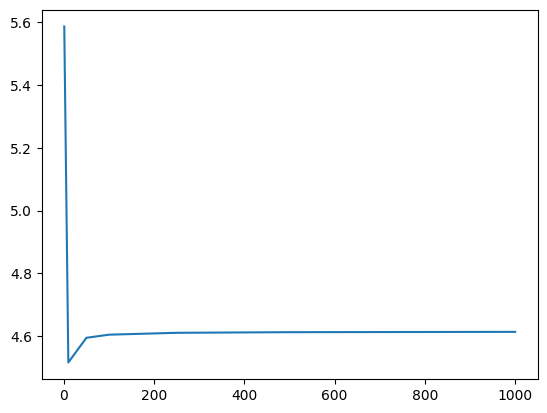

In [30]:
plt.plot(convergence_table["Steps"], convergence_table["Call Price"], label="Call Price")

### Binomial Plot

In [31]:
import matplotlib.pyplot as plt
def plot_binomial_tree(values, title, N=None, decimals=2):

    if N is None:
        N = values.shape[0] - 1

    N = min(N, values.shape[0] - 1)

    fig, ax = plt.subplots(
        figsize=(3 * N + 3, 2 * N + 3)
    )

    # Draw the branches
    for j in range(N):
        for i in range(j + 1):

            x_current = j
            y_current = 2 * i - j

            x_next = j + 1

            y_down = 2 * i - (j + 1)
            y_up = 2 * (i + 1) - (j + 1)

            ax.plot(
                [x_current, x_next],
                [y_current, y_down],
                color="gray",
                linewidth=1
            )

            ax.plot(
                [x_current, x_next],
                [y_current, y_up],
                color="gray",
                linewidth=1
            )

    # Draw the nodes and values
    for j in range(N + 1):
        for i in range(j + 1):

            value = values[j, i]

            if not np.isfinite(value):
                continue

            x = j
            y = 2 * i - j

            ax.scatter(
                x,
                y,
                s=700,
                color="skyblue",
                edgecolor="black",
                zorder=3
            )

            ax.text(
                x,
                y,
                f"{value:.{decimals}f}",
                ha="center",
                va="center",
                fontsize=9,
                zorder=4
            )

    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Node position")
    ax.set_xticks(range(N + 1))
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

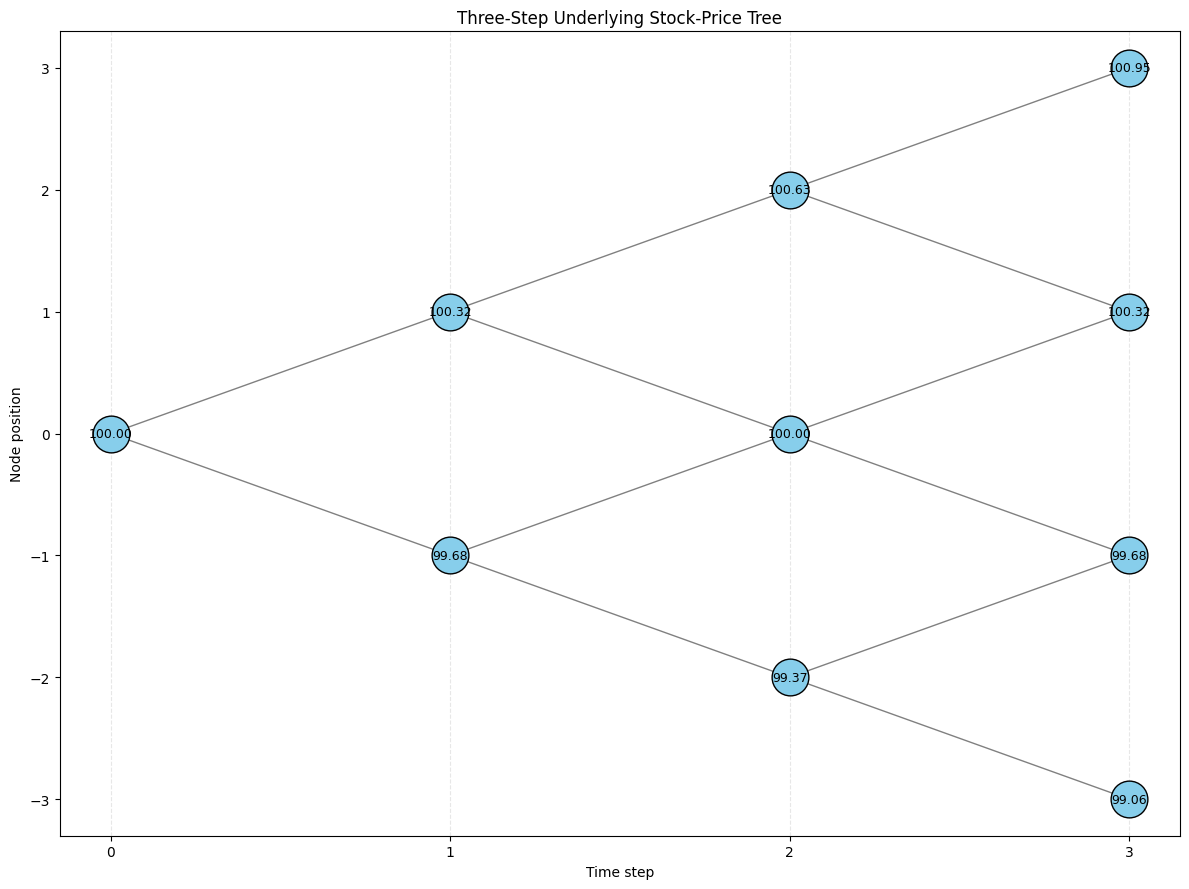

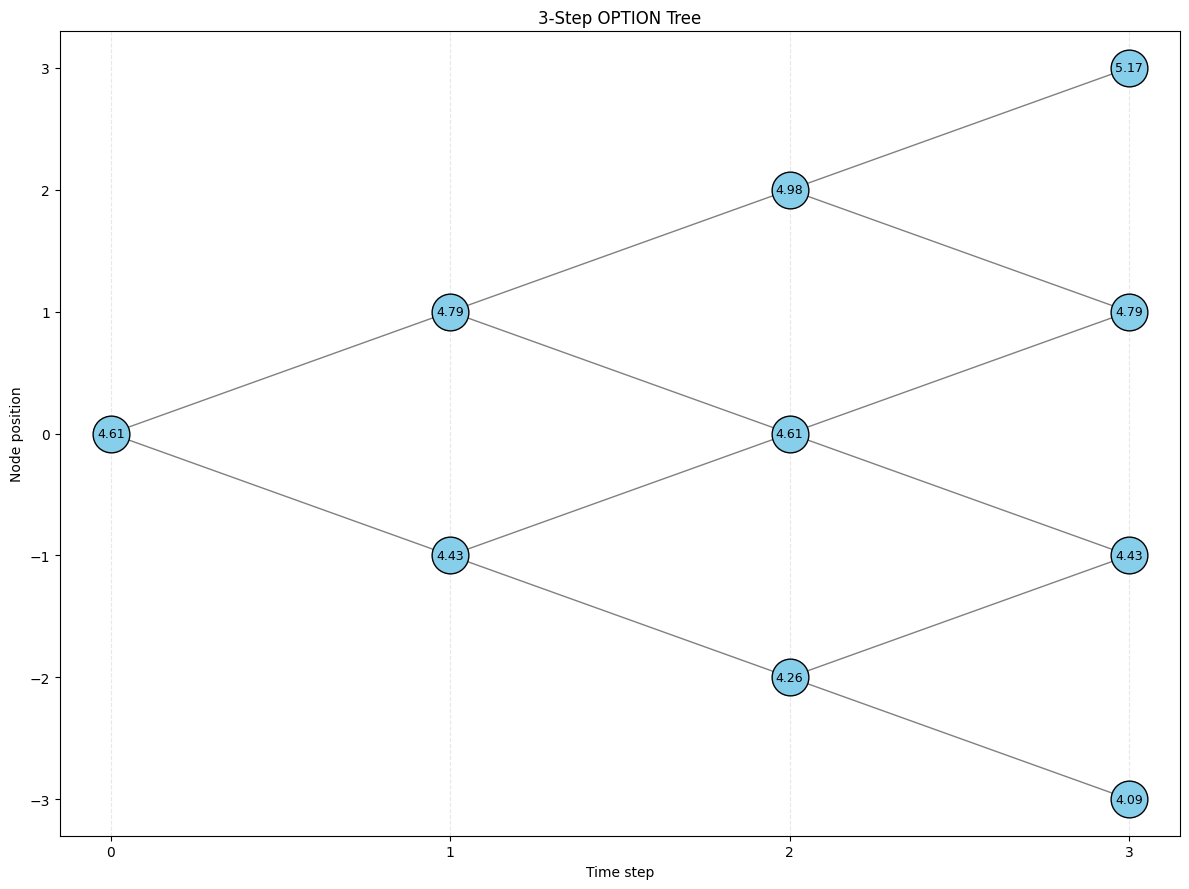

In [32]:
plot_binomial_tree(
    call["underlying_prices"],
    "Three-Step Underlying Stock-Price Tree",
    N=3,
    decimals=2
)
plot_binomial_tree(
    call["option_prices"],
    "3-Step OPTION Tree",
    N=3,
    decimals=2
)

## Question 5

Compute the Greek Delta for the European call and put at time 0:

*   How do they compare?
*   Comment briefly on the signs of Delta for both options. What does Delta
proxy for, and why does it make sense to obtain a positive/negative Delta
for each option?

While computing Delta using the 250-step binomial tree, it was approximately 0.56 for call and -0.43 for put.

The call delta is positive whereas put delta is negative. The reason for call Delta being positive is because the value of a call increases when the underlying stock price increases, whereas for put, Delta is negative because the value of a put decreases when the underlying stock price increases.

Delta represents the approximate chane in the option price resulting from a one-dollar change in the underlying asset price. It usually proxy for the hedge ratio indicating the number of underlying units required to hedge one option.

The call and put Deltas have opposite signs, reflecting their opposite responses to changes in the stock price.


In [33]:
call = european_binomial_price_delta(
    S0,K,T,r,sigma,250,"C"
)
put = european_binomial_price_delta(
    S0,K,T,r,sigma,250,"P"
)
call_delta = call['delta']
put_delta = put['delta']

print(f"Call Delta: {call_delta}")
print(f"Put Delta: {put_delta}")


Call Delta: 0.5693919479184976
Put Delta: -0.43060805208150454


In [34]:
call_delta + put_delta

np.float64(0.13878389583699302)

## Question 6

Compute Vega by re-pricing the call and put for a 5% increase in volatility (from 20% to 25%). How do the prices change, and what is the differential impact on the call versus the put?


We estimated the Vega by increasing the volatility from 20% to 25%, representing a five-percentage-point increase:

$$
\text{Vega} \approx \frac{V(25\%) - V(20\%)}{0.05}
$$

As per the results, we say that both the call and put increased in value by approximately $0.98 when volatility increased. This occurs because higher volatility increases the range of possible future stock prices, improving the likelihood of a favourable payoff for both options.

The impact of volatility was approximately the same for the call and put. However, the put experienced a larger percentage impact because its initial price was lower. The call increased by approximately 21%, while the put increased by approximately 29%. Therefore, volatility had a similar dollar impact on both options but a larger proportional impact on the put.

In [35]:
N = 250
base_volatility = 0.20
bumped_volatility = 0.25
volatility_change = bumped_volatility - base_volatility

In [36]:
vega_rows = []

for option_type, option_name in [
    ("C", "European Call"),
    ("P", "European Put")
]:

    base_result = european_binomial_price_delta(
        S0, K, T, r,
        base_volatility,
        N,
        option_type
    )

    bumped_result = european_binomial_price_delta(
        S0, K, T, r,
        bumped_volatility,
        N,
        option_type
    )

    base_price = base_result["price"]
    bumped_price = bumped_result["price"]

    price_change = bumped_price - base_price

    approximate_vega = (
        price_change / volatility_change
    )

    percentage_change = (
        price_change / base_price
    )

    vega_rows.append({
        "Option": option_name,
        "Price at 20%": base_price,
        "Price at 25%": bumped_price,
        "Price Change": price_change,
        "Approx. Vega": approximate_vega,
        "Percentage Change": percentage_change
    })

In [37]:
vega_rows

[{'Option': 'European Call',
  'Price at 20%': np.float64(4.611005674507408),
  'Price at 25%': np.float64(5.59342575030205),
  'Price Change': np.float64(0.982420075794642),
  'Approx. Vega': np.float64(19.648401515892843),
  'Percentage Change': np.float64(0.2130598279733398)},
 {'Option': 'European Put',
  'Price at 20%': np.float64(3.368785723894939),
  'Price at 25%': np.float64(4.351205799689565),
  'Price Change': np.float64(0.9824200757946255),
  'Approx. Vega': np.float64(19.648401515892516),
  'Percentage Change': np.float64(0.2916243882257867)}]

In [38]:
vega_table = pd.DataFrame(vega_rows)
vega_table.style.format({
    "Price at 20%": "${:.2f}",
    "Price at 25%": "${:.2f}",
    "Price Change": "${:.2f}",
    "Approx. Vega": "{:.4f}",
    "Percentage Change": "{:.2%}"
})

,Option,Price at 20%,Price at 25%,Price Change,Approx. Vega,Percentage Change
0,European Call,$4.61,$5.59,$0.98,19.6484,21.31%
1,European Put,$3.37,$4.35,$0.98,19.6484,29.16%


# Question 11-12

## Question 11

In [39]:
#Checking the base again
print("Underlying Price :", S0)
print("Strike Price :", K)
print("Time to Maturity :", T)
print("Risk-free Rate :", r)
print("Volatility :", sigma)
print("Number of Steps :", N)

Underlying Price : 100
Strike Price : 100
Time to Maturity : 0.25
Risk-free Rate : 0.05
Volatility : 0.2
Number of Steps : 250


In [40]:
# Heston parameters supplied in the brief
v0 = 0.04
kappa = 1.85
theta = 0.04
xi = 0.35
RHOS = np.array([-0.30, -0.70])

# Reproducible Monte Carlo design
N_PATHS = 1_000_000       # total paths; 500,000 independent antithetic pairs
N_STEPS = 126             # half-trading-day resolution over about 63 trading days
SEED = 6_202_026
BUMP = 1.0                # $1 = 1% of spot for central finite differences

if N_PATHS % 2 != 0:
    raise ValueError("N_PATHS must be even when antithetic variates are used.")

feller_left = 2.0 * kappa * theta
feller_right = xi**2
print(f"Feller check: 2*kappa*theta = {feller_left:.4f}; xi^2 = {feller_right:.4f}")
print("Feller condition satisfied:", feller_left > feller_right)

Feller check: 2*kappa*theta = 0.1480; xi^2 = 0.1225
Feller condition satisfied: True


In [42]:
from scipy.stats import norm
def black_scholes_call_put(S0:int, K:int, r:int, T:int, sigma:int) -> tuple:
  d1 = np.log(S0/K) + (r +(1/2) *( sigma**2)) * T / (sigma * np.sqrt(T))
  d2 = d1 - (sigma * np.sqrt(T))

  call = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
  put = call - S0 + K * np.exp(-r*T) #from put call parity

  return call, put
bs_call, bs_put = black_scholes_call_put(S0, K, r, T,sigma)
bs_call, bs_put

In [59]:
Q4_CALL = q4_call
Q4_PUT = q4_put

if Q4_CALL is None or Q4_PUT is None:
    step1_prices = {"Call": bs_call, "Put": bs_put}
    baseline_label = "Black-Scholes check (replace with Q4 values)"
else:
    step1_prices = {"Call": float(Q4_CALL), "Put": float(Q4_PUT)}
    baseline_label = "Question 4 binomial tree"

baseline_table = pd.DataFrame(
    {
        "Baseline used": [baseline_label, baseline_label],
        "Option": ["Call", "Put"],
        "Price ($)": [step1_prices["Call"], step1_prices["Put"]],
    }
)
baseline_table["Price ($)"] = baseline_table["Price ($)"].round(2)
display(baseline_table)

,Baseline used,Option,Price ($)
0,Question 4 binomial tree,Call,4.61
1,Question 4 binomial tree,Put,3.37


### BS model using Monte Carlo

In [167]:
def bs_monte(S0:int, K:int, r:int, T:int, sigma:int, n_paths:int = 500, n_steps:int = 250) -> tuple:

  Z = np.random.normal(0,1,size=(n_paths,n_steps))
  dt = T/n_steps
  log_returns = ((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
  S_paths = S0 * np.exp(np.cumsum(log_returns, axis=1))
  S_T = S_paths[:,-1]
  call_payoffs = np.maximum(S_T - K, 0)
  put_payoffs = np.maximum(K - S_T, 0)

  call_price = np.exp(-r * T) * np.mean(call_payoffs)
  put_price = np.exp(-r * T) * np.mean(put_payoffs)

  return S_paths,call_price,put_price

paths, call_price, put_price = bs_monte(S0,K,r,T,sigma)


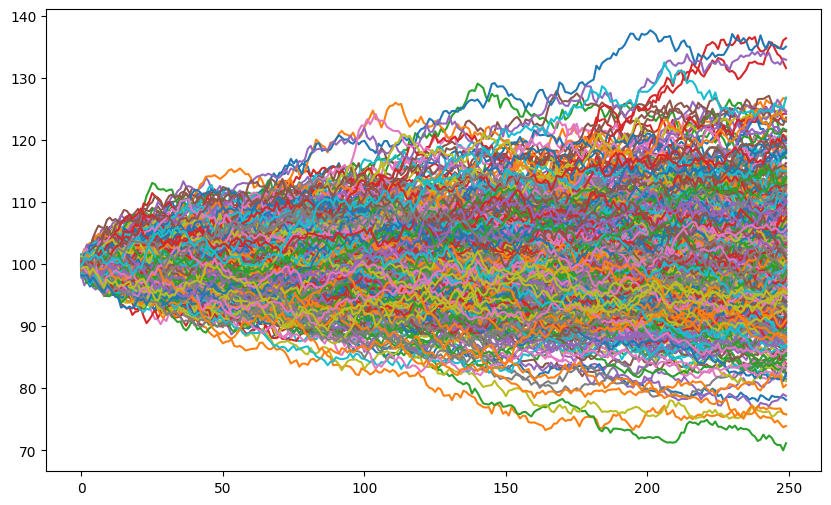

In [169]:
plt.figure(figsize=(10,6))
plt.plot(paths.T)
plt.show()